In [1]:
#cell 1
import os, pathlib, zipfile
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_HEAD = 8      # phase 1: train only the new classification head
EPOCHS_FINE = 20     # phase 2: fine-tune top of EfficientNet
WEIGHTS = "imagenet"
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
#cell 2
from google.colab import files
uploaded = files.upload()
for fn in uploaded:
    zipfile.ZipFile(fn).extractall("/content/dataset_extracted")
print("Extracted.")

Saving test.zip to test.zip
Extracted.


In [3]:
#cell 3
# Folder that directly contains the class sub-folders (akiec, bcc, ...)
DATA_DIR = "/content/dataset_extracted/test"
print(sorted(os.listdir(DATA_DIR)))

['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [4]:
#cell 4
data_dir = pathlib.Path(DATA_DIR)
class_names = sorted(d.name for d in data_dir.iterdir() if d.is_dir() and not d.name.startswith((".", "_")))
paths, labels = [], []
for i, c in enumerate(class_names):
    for p in (data_dir / c).iterdir():
        if p.suffix.lower() in (".jpg", ".jpeg", ".png"):
            paths.append(str(p)); labels.append(i)
paths, labels = np.array(paths), np.array(labels)
num_classes = len(class_names)
print("Classes:", class_names, "| total images:", len(paths))

tr_p, tmp_p, tr_y, tmp_y = train_test_split(paths, labels, test_size=0.30, stratify=labels, random_state=SEED)
va_p, te_p, va_y, te_y = train_test_split(tmp_p, tmp_y, test_size=0.50, stratify=tmp_y, random_state=SEED)

print(f"{'class':8s} {'train':>6s} {'val':>5s} {'test':>5s}")
for i, c in enumerate(class_names):
    print(f"{c:8s} {(tr_y==i).sum():6d} {(va_y==i).sum():5d} {(te_y==i).sum():5d}")

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'] | total images: 1503
class     train   val  test
akiec        34     7     8
bcc          54    11    12
bkl         116    24    25
df           12     3     2
mel         117    25    25
nv          704   151   151
vasc         15     4     3


In [5]:
#cell 5
AUTOTUNE = tf.data.AUTOTUNE

def load_img(path, label):
    img = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    return tf.cast(tf.round(img), tf.uint8), label

def make_ds(p, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((p, y.astype("int32")))
    ds = ds.map(load_img, num_parallel_calls=AUTOTUNE).cache()
    if training:
        ds = ds.shuffle(len(p), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32), y), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_ds(tr_p, tr_y, training=True)
val_ds   = make_ds(va_p, va_y)
test_ds  = make_ds(te_p, te_y)

In [6]:
#cell 6
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
], name="data_augmentation")

base_model = tf.keras.applications.EfficientNetB0(
    input_shape=IMG_SIZE + (3,), include_top=False, weights=WEIGHTS)
base_model.trainable = False          # phase 1: frozen backbone

gap   = layers.GlobalAveragePooling2D()
drop1 = layers.Dropout(0.4)
fc    = layers.Dense(256, activation="relu")
drop2 = layers.Dropout(0.3)
out   = layers.Dense(num_classes, activation="softmax")
head  = [gap, drop1, fc, drop2, out]

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)     # keeps BatchNorm in inference mode
for l in head: x = l(x)
model = models.Model(inputs, x)

def compile_model(lr):
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])

compile_model(1e-3)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,306 (16.71 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [7]:
#cell 7
cw = compute_class_weight("balanced", classes=np.arange(num_classes), y=tr_y)
class_weight_dict = dict(enumerate(cw))
print("Class weights:", {class_names[k]: round(v, 2) for k, v in class_weight_dict.items()})

class MacroF1Checkpoint(tf.keras.callbacks.Callback):
    def __init__(self, val_ds, y_val, path, patience=6):
        super().__init__()
        self.val_ds, self.y_val, self.path, self.patience = val_ds, y_val, path, patience
        self.best, self.f1s = -1.0, []
    def on_train_begin(self, logs=None): self.wait = 0
    def on_epoch_end(self, epoch, logs=None):
        preds = np.argmax(self.model.predict(self.val_ds, verbose=0), axis=1)
        f1 = f1_score(self.y_val, preds, average="macro")
        self.f1s.append(f1)
        print(f"   val macro-F1: {f1:.4f} (best {max(self.best, f1):.4f})")
        if f1 > self.best:
            self.best, self.wait = f1, 0
            self.model.save_weights(self.path)
        else:
            self.wait += 1
            if self.wait >= self.patience: self.model.stop_training = True

CKPT = "best_skin.weights.h5"
f1_cb = MacroF1Checkpoint(val_ds, va_y, CKPT)

print("Phase 1: training classification head")
h1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
               callbacks=[f1_cb], class_weight=class_weight_dict)

Class weights: {'akiec': np.float64(4.42), 'bcc': np.float64(2.78), 'bkl': np.float64(1.3), 'df': np.float64(12.52), 'mel': np.float64(1.28), 'nv': np.float64(0.21), 'vasc': np.float64(10.02)}
Phase 1: training classification head
Epoch 1/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.3549 - loss: 1.8775   val macro-F1: 0.1989 (best 0.1989)
33/33 ━━━━━━━━━━━━━━━━━━━━ 35s 427ms/step - accuracy: 0.3194 - loss: 2.0945 - val_accuracy: 0.3822 - val_loss: 1.7175
Epoch 2/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.2831 - loss: 1.8147   val macro-F1: 0.3458 (best 0.3458)
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.3337 - loss: 1.6923 - val_accuracy: 0.6178 - val_loss: 1.2133
Epoch 3/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5310 - loss: 1.4406   val macro-F1: 0.3312 (best 0.3458)
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.4829 - loss: 1.5544 - val_accuracy: 0.4533 - val_loss: 1.4280
Epoch 4/8
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - ac

In [8]:
#cell 8
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
compile_model(2e-5)

print("Phase 2: fine-tuning")
h2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINE,
               callbacks=[f1_cb], class_weight=class_weight_dict)

Phase 2: fine-tuning
Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5606 - loss: 1.0760   val macro-F1: 0.4075 (best 0.4075)
33/33 ━━━━━━━━━━━━━━━━━━━━ 33s 519ms/step - accuracy: 0.5684 - loss: 1.0955 - val_accuracy: 0.6178 - val_loss: 1.0609
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5750 - loss: 1.1510   val macro-F1: 0.3771 (best 0.4075)
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - accuracy: 0.5741 - loss: 1.0351 - val_accuracy: 0.6178 - val_loss: 1.0246
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5931 - loss: 0.9811   val macro-F1: 0.3956 (best 0.4075)
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.5884 - loss: 1.0189 - val_accuracy: 0.6356 - val_loss: 0.9932
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5477 - loss: 1.1036   val macro-F1: 0.3952 (best 0.4075)
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - accuracy: 0.5808 - loss: 1.0396 - val_accuracy: 0.6222 - val_loss: 1.0026
Epoch 5/20
33/33 ━━━━━

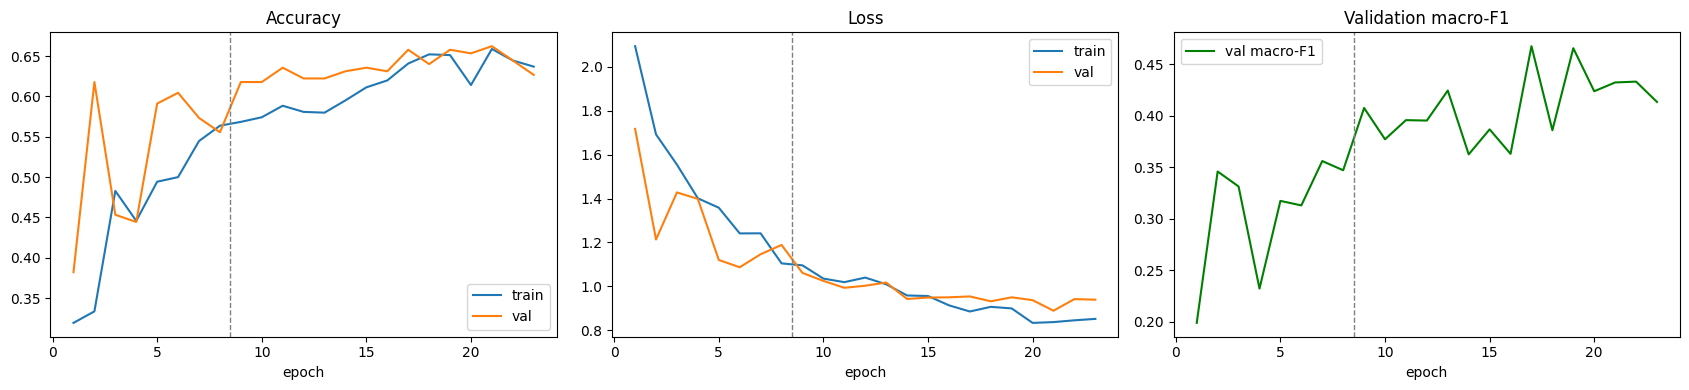

In [9]:
#cell 9
hist = {k: h1.history[k] + h2.history[k] for k in ["accuracy", "val_accuracy", "loss", "val_loss"]}
ep = range(1, len(hist["loss"]) + 1)
split = len(h1.history["loss"]) + 0.5

fig, ax = plt.subplots(1, 3, figsize=(17, 4))
ax[0].plot(ep, hist["accuracy"], label="train"); ax[0].plot(ep, hist["val_accuracy"], label="val"); ax[0].set_title("Accuracy")
ax[1].plot(ep, hist["loss"], label="train"); ax[1].plot(ep, hist["val_loss"], label="val"); ax[1].set_title("Loss")
ax[2].plot(ep, f1_cb.f1s, label="val macro-F1", color="green"); ax[2].set_title("Validation macro-F1")
for a in ax:
    a.axvline(split, color="gray", ls="--", lw=1); a.set_xlabel("epoch"); a.legend()
plt.tight_layout(); plt.savefig("training_curves.png", dpi=150); plt.show()

Test accuracy: 0.6593 | macro-F1: 0.4333
              precision    recall  f1-score   support

       akiec      0.500     0.375     0.429         8
         bcc      0.444     0.333     0.381        12
         bkl      0.600     0.360     0.450        25
          df      0.100     0.500     0.167         2
         mel      0.209     0.360     0.265        25
          nv      0.896     0.795     0.842       151
        vasc      0.333     1.000     0.500         3

    accuracy                          0.659       226
   macro avg      0.440     0.532     0.433       226
weighted avg      0.734     0.659     0.685       226



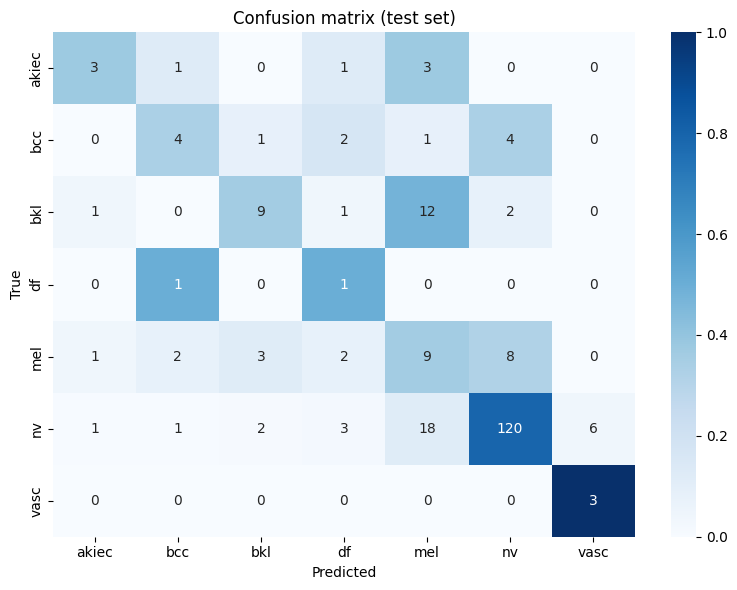

In [10]:
#cell 10
model.load_weights(CKPT)
probs = model.predict(test_ds, verbose=0)
y_pred = probs.argmax(1)

print("Test accuracy: %.4f | macro-F1: %.4f" % (accuracy_score(te_y, y_pred), f1_score(te_y, y_pred, average="macro")))
print(classification_report(te_y, y_pred, target_names=class_names, digits=3, zero_division=0))

cm = confusion_matrix(te_y, y_pred, labels=range(num_classes))
cmn = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
plt.figure(figsize=(8, 6))
sns.heatmap(cmn, annot=cm, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion matrix (test set)")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=150); plt.show()

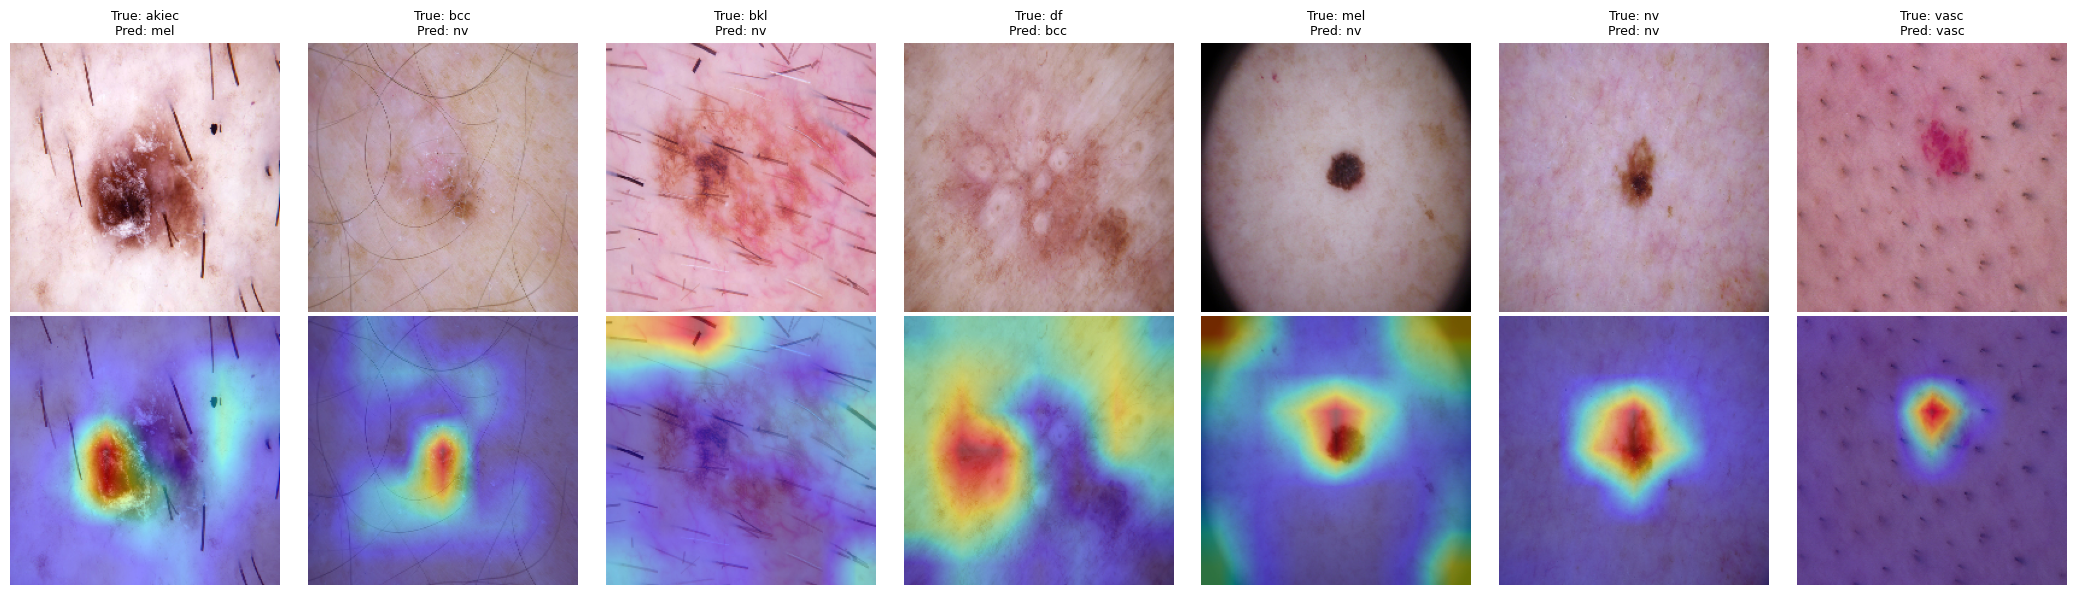

In [11]:
#cell 11
def load_arr(path):
    return tf.keras.utils.img_to_array(tf.keras.utils.load_img(path, target_size=IMG_SIZE))

def grad_cam(img_arr):
    x = tf.convert_to_tensor(img_arr[None], dtype=tf.float32)
    with tf.GradientTape() as tape:
        conv = base_model(x, training=False)
        tape.watch(conv)
        h = conv
        for l in head: h = l(h, training=False)
        cls = tf.argmax(h[0]); score = h[0, cls]
    grads = tape.gradient(score, conv)
    w = tf.reduce_mean(grads, axis=(1, 2))[0]
    cam = tf.nn.relu(tf.reduce_sum(conv[0] * w, axis=-1))
    cam = cam / (tf.reduce_max(cam) + 1e-8)
    cam = tf.image.resize(cam[..., None], IMG_SIZE)[..., 0].numpy()
    return cam, int(cls)

idxs = [np.where(te_y == c)[0][0] for c in range(num_classes) if (te_y == c).any()]
fig, axes = plt.subplots(2, len(idxs), figsize=(3 * len(idxs), 6))
for j, i in enumerate(idxs):
    arr = load_arr(te_p[i]); cam, pred = grad_cam(arr)
    axes[0, j].imshow(arr.astype("uint8")); axes[0, j].set_title(f"True: {class_names[te_y[i]]}\nPred: {class_names[pred]}", fontsize=9)
    axes[1, j].imshow(arr.astype("uint8")); axes[1, j].imshow(cam, cmap="jet", alpha=0.45)
    axes[0, j].axis("off"); axes[1, j].axis("off")
plt.tight_layout(); plt.savefig("gradcam.png", dpi=150); plt.show()

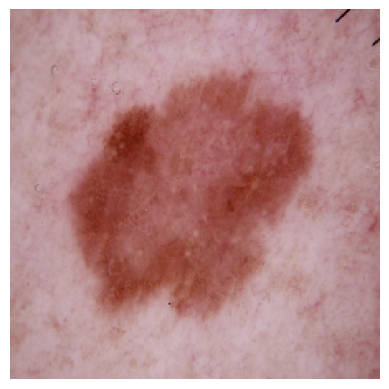

mel     82.1%
nv       9.9%
bkl      3.9%


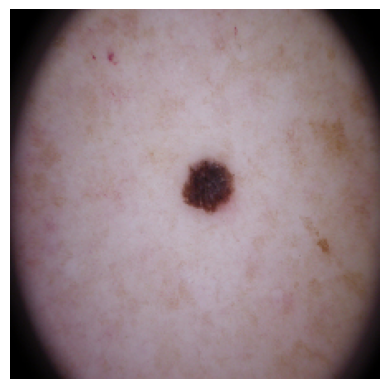

nv      74.5%
vasc     8.7%
mel      7.3%


In [13]:
#cell 12
def predict_skin_lesion(img_path):
    arr = load_arr(img_path)                       # 0-255, NO /255 (EfficientNet rescales internally)
    p = model.predict(arr[None], verbose=0)[0]
    top = np.argsort(p)[::-1][:3]
    plt.imshow(arr.astype("uint8")); plt.axis("off"); plt.show()
    for k in top: print(f"{class_names[k]:6s} {p[k]*100:5.1f}%")

predict_skin_lesion("/content/ISIC_0024516.jpg")   # <- put a real path here
predict_skin_lesion(te_p[0])